In [1]:
#Machine Learning Project - Post Partum Depression [Stage 1 and 2 Codes Combined]

In [2]:
#Install relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, log_loss
from sklearn.inspection import permutation_importance
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [3]:
# Loading the dataset onto a dataframe (using Pandas) - (Link: https://www.kaggle.com/datasets/parvezalmuqtadir2348/postpartum-depression/data)
df = pd.read_csv('post natal data.csv')
df.head()

,Timestamp,Age,Feeling sad or Tearful,Irritable towards baby & partner,Trouble sleeping at night,Problems concentrating or making decision,Overeating or loss of appetite,Feeling anxious,Feeling of guilt,Problems of bonding with baby,Suicide attempt
0,6/14/2022 20:02,35-40,Yes,Yes,Two or more days a week,Yes,Yes,Yes,No,Yes,Yes
1,6/14/2022 20:03,40-45,Yes,No,No,Yes,Yes,No,Yes,Yes,No
2,6/14/2022 20:04,35-40,Yes,No,Yes,Yes,Yes,Yes,No,Sometimes,No
3,6/14/2022 20:05,35-40,Yes,Yes,Yes,Yes,No,Yes,Maybe,No,No
4,6/14/2022 20:06,40-45,Yes,No,Two or more days a week,Yes,No,Yes,No,Yes,No


In [4]:
# Delete the timestamp feature as it only represents when the candidate has filled-in their details
df = df.drop(columns=["Timestamp"])

In [5]:
#Print the information of the dataset, contained within the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 10 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   Age                                        1503 non-null   object
 1   Feeling sad or Tearful                     1503 non-null   object
 2   Irritable towards baby & partner           1497 non-null   object
 3   Trouble sleeping at night                  1503 non-null   object
 4   Problems concentrating or making decision  1491 non-null   object
 5   Overeating or loss of appetite             1503 non-null   object
 6   Feeling anxious                            1503 non-null   object
 7   Feeling of guilt                           1494 non-null   object
 8   Problems of bonding with baby              1503 non-null   object
 9   Suicide attempt                            1503 non-null   object
dtypes: object(10)
memory usage: 117.6+ K

In [6]:
# For Descriptive Statistics of Data
df.describe()

,Age,Feeling sad or Tearful,Irritable towards baby & partner,Trouble sleeping at night,Problems concentrating or making decision,Overeating or loss of appetite,Feeling anxious,Feeling of guilt,Problems of bonding with baby,Suicide attempt
count,1503,1503,1497,1503,1491,1503,1503,1494,1503,1503
unique,5,3,3,3,3,3,2,3,3,3
top,40-45,Yes,Yes,Two or more days a week,No,No,Yes,No,No,No
freq,364,536,555,640,583,841,980,624,557,709


In [7]:
# Check for missing values; best to remove them
df.isna().sum()

Age                                           0
Feeling sad or Tearful                        0
Irritable towards baby & partner              6
Trouble sleeping at night                     0
Problems concentrating or making decision    12
Overeating or loss of appetite                0
Feeling anxious                               0
Feeling of guilt                              9
Problems of bonding with baby                 0
Suicide attempt                               0
dtype: int64

In [8]:
# Remove records with any NaN (Not-a-Number) values
df = df.dropna()
new_num_rows = len(df)
print("Number of rows after dropna:", new_num_rows)

Number of rows after dropna: 1491


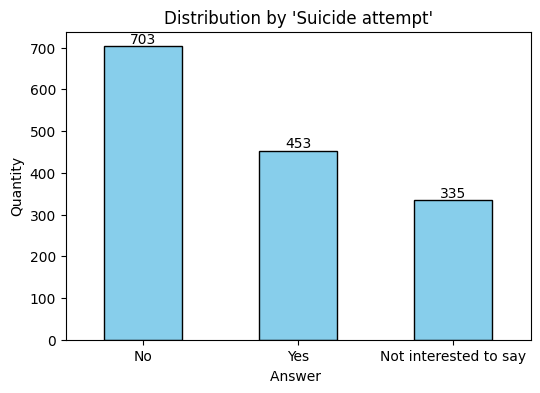

In [9]:
# Distribution plot of the target 'Suicide attempt'/ Class Distribution (For checking if the classes are equally balanced or not).
# The plot shows significant class imbalance.
plt.figure(figsize=(6,4))
ax = df["Suicide attempt"].value_counts().plot(kind="bar", color="skyblue", edgecolor="black")

plt.title("Distribution by 'Suicide attempt'")
plt.xlabel("Answer ")
plt.ylabel("Quantity")
plt.xticks(rotation=0)

for p in ax.patches:
    ax.annotate(
        str(p.get_height()),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom"
    )
    
plt.show()

In [10]:
# Initialize LabelEncoder
le = LabelEncoder()

# Dictionary to store mappings for each column
label_mappings = {}

# Columns to encode
columns_to_encode = df.columns.tolist()

for column in columns_to_encode:
    df[column] = le.fit_transform(df[column])
    
    # Store mapping: original class -> encoded label
    label_mappings[column] = dict(zip(le.classes_, le.transform(le.classes_)))

# Print the mapping for all columns
for col, mapping in label_mappings.items():
    print(f"Column: {col}")
    for original_class, encoded_label in mapping.items():
        print(f" {original_class} -> {encoded_label}")
    print("-" * 30)

Column: Age
 25-30 -> 0
 30-35 -> 1
 35-40 -> 2
 40-45 -> 3
 45-50 -> 4
------------------------------
Column: Feeling sad or Tearful
 No -> 0
 Sometimes -> 1
 Yes -> 2
------------------------------
Column: Irritable towards baby & partner
 No -> 0
 Sometimes -> 1
 Yes -> 2
------------------------------
Column: Trouble sleeping at night
 No -> 0
 Two or more days a week -> 1
 Yes -> 2
------------------------------
Column: Problems concentrating or making decision
 No -> 0
 Often -> 1
 Yes -> 2
------------------------------
Column: Overeating or loss of appetite
 No -> 0
 Not at all -> 1
 Yes -> 2
------------------------------
Column: Feeling anxious
 No -> 0
 Yes -> 1
------------------------------
Column: Feeling of guilt
 Maybe -> 0
 No -> 1
 Yes -> 2
------------------------------
Column: Problems of bonding with baby
 No -> 0
 Sometimes -> 1
 Yes -> 2
------------------------------
Column: Suicide attempt
 No -> 0
 Not interested to say -> 1
 Yes -> 2
-------------------------

In [11]:
# Label encoding, to reduce the computation time when the models work on the dataset for training/testing
le = LabelEncoder()
columns_to_encode = df.columns.tolist()

for column in columns_to_encode:
    df[column] = le.fit_transform(df[column])

In [12]:
# Separate features and target variable (taking 'Suicide attempt' as the target that which is to be predicted)
X = df.drop(['Suicide attempt'], axis=1)
y = df['Suicide attempt']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training sample size:", X_train.shape)
print("Test sample size:", X_test.shape)
print("Training sample size:", y_train.shape)
print("Test sample size:", y_test.shape)

Training sample size: (1192, 9)
Test sample size: (299, 9)
Training sample size: (1192,)
Test sample size: (299,)


Average Training Accuracy (5-fold CV): 0.9547
Average Validation Accuracy (5-fold CV): 0.8473
Train Accuracy: 0.9723
Test Accuracy: 0.8662
K-Nearest Neighbors Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.92      0.89       140
           1       0.83      0.79      0.81        73
           2       0.91      0.84      0.87        86

    accuracy                           0.87       299
   macro avg       0.87      0.85      0.86       299
weighted avg       0.87      0.87      0.87       299

Error Rate: 0.1338
kNN Log Loss (Cross-Entropy): 1.0189


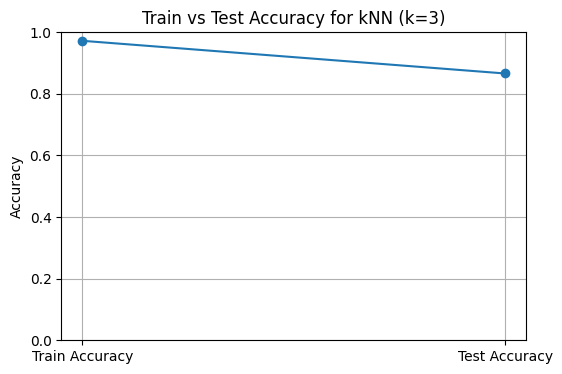

In [13]:
# K-Fold cross-validation (5 splits) for KNN
kf = KFold(n_splits=5, shuffle=True, random_state=42)
train_accuracies = []
val_accuracies = []

for train_index, val_index in kf.split(X_train):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]
    
    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(X_train_fold, y_train_fold)
    
    train_preds_fold = knn.predict(X_train_fold)
    val_preds_fold = knn.predict(X_val_fold)
    
    train_acc_fold = accuracy_score(y_train_fold, train_preds_fold)
    val_acc_fold = accuracy_score(y_val_fold, val_preds_fold)
    
    train_accuracies.append(train_acc_fold)
    val_accuracies.append(val_acc_fold)
    
print(f'Average Training Accuracy (5-fold CV): {np.mean(train_accuracies):.4f}')
print(f'Average Validation Accuracy (5-fold CV): {np.mean(val_accuracies):.4f}')

# Train final model on full training data
knn_final = KNeighborsClassifier(n_neighbors=3)
knn_final.fit(X_train, y_train)

# Predict on train and test sets
train_preds = knn_final.predict(X_train)
test_preds = knn_final.predict(X_test)

# Predict class labels and probabilities
y_pred_knn = knn_final.predict(X_test)
y_proba_knn = knn_final.predict_proba(X_test)

# Calculate accuracy
train_acc = accuracy_score(y_train, train_preds)
test_acc = accuracy_score(y_test, test_preds)

# Log Loss (Cross-Entropy)
logloss_knn = log_loss(y_test, y_proba_knn)

# Print results
print(f'Train Accuracy: {train_acc:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

# Classification report
report = classification_report(y_test, test_preds)
accuracy = accuracy_score(y_test, test_preds)
error_rate = 1 - accuracy
print("K-Nearest Neighbors Classification Report:")
print(report)

#Taken two different kinds of error calculations methods, to see how it varies, both sensitive and non-sensitive methods (relatively when comparing)
print(f"Error Rate: {error_rate:.4f}")
print(f"kNN Log Loss (Cross-Entropy): {logloss_knn:.4f}")

# Plot train vs test accuracy
plt.figure(figsize=(6, 4))
plt.plot(['Train Accuracy', 'Test Accuracy'], [train_acc, test_acc], marker='o', linestyle='-')
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy for kNN (k=3)')
plt.grid(True)
plt.show()

In [14]:
# Permutation importance (Feature Importance)
"""The box plot displays minimum, first quartile, median, third quartile, and maximum values of the importance scores obtained from repeated permutations.
This helps understand not just the average importance, but also the consistency and stability of that importance measure."""
result = permutation_importance(knn, X_test, y_test, n_repeats=10, random_state=42)
importance_means = result.importances_mean
importance_std = result.importances_std
feature_names = X.columns

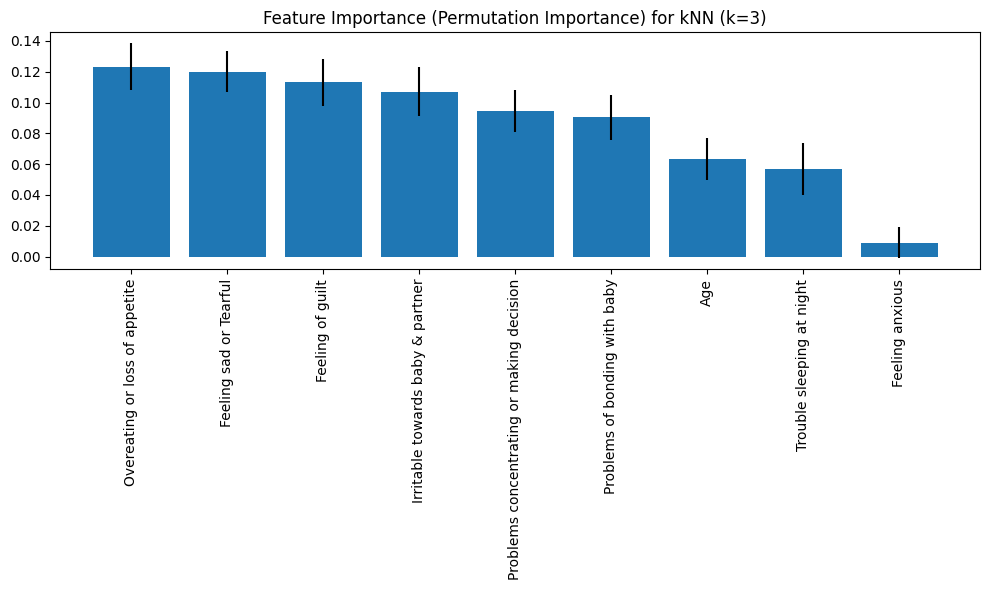

In [15]:
# Plot feature importance
plt.figure(figsize=(10, 6))
indices = np.argsort(importance_means)[::-1]
plt.bar(range(len(feature_names)), importance_means[indices], yerr=importance_std[indices], align='center')
plt.xticks(range(len(feature_names)), feature_names[indices], rotation=90)
plt.title('Feature Importance (Permutation Importance) for kNN (k=3)')
plt.tight_layout()
plt.show()

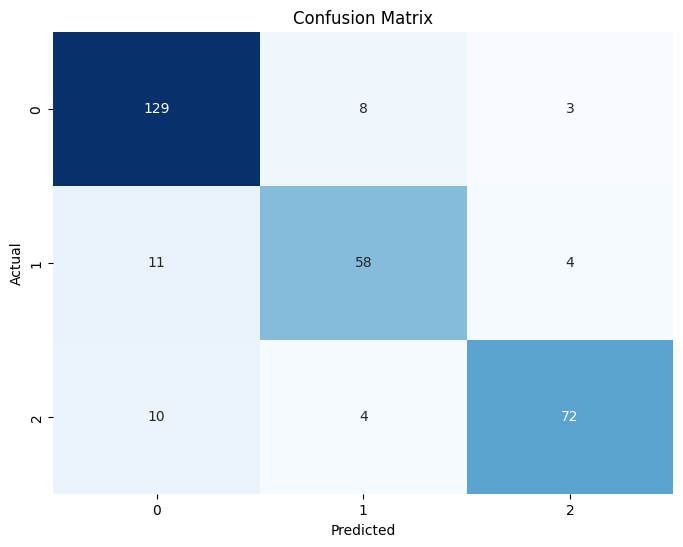

In [16]:
# Compute confusion matrix
cm = confusion_matrix(y_test, test_preds)

# Plot confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Average Training Accuracy (5-fold CV): 0.9966
Average Validation Accuracy (5-fold CV): 0.9363
Train Accuracy: 0.9966
Test Accuracy: 0.9632
Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       140
           1       0.95      0.96      0.95        73
           2       0.96      0.92      0.94        86

    accuracy                           0.96       299
   macro avg       0.96      0.96      0.96       299
weighted avg       0.96      0.96      0.96       299

Error Rate: 0.0368
Log Loss (Cross-Entropy): 1.1028


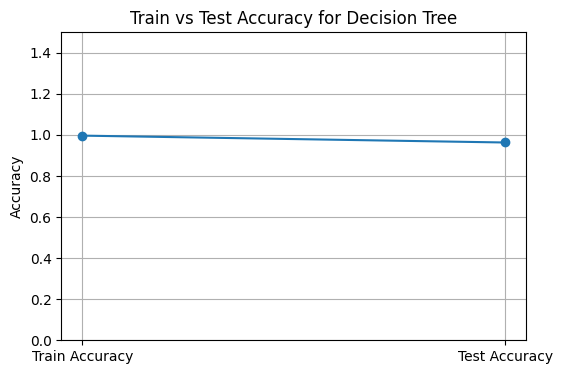

In [17]:
# K-Fold cross-validation (5 splits) for Decision Tree model
kf = KFold(n_splits=5, shuffle=True, random_state=42)
train_accuracies = []
val_accuracies = []

for train_index, val_index in kf.split(X_train):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]
    
    dt = DecisionTreeClassifier(random_state=42)
    dt.fit(X_train_fold, y_train_fold)
    
    train_preds_fold = dt.predict(X_train_fold)
    val_preds_fold = dt.predict(X_val_fold)
    
    train_acc_fold = accuracy_score(y_train_fold, train_preds_fold)
    val_acc_fold = accuracy_score(y_val_fold, val_preds_fold)
    
    train_accuracies.append(train_acc_fold)
    val_accuracies.append(val_acc_fold)
    
print(f'Average Training Accuracy (5-fold CV): {np.mean(train_accuracies):.4f}')
print(f'Average Validation Accuracy (5-fold CV): {np.mean(val_accuracies):.4f}')

# Train final model on full training data
dt_final = DecisionTreeClassifier(random_state=42)
dt_final.fit(X_train, y_train)

# Predict on train and test sets
train_preds = dt_final.predict(X_train)
test_preds = dt_final.predict(X_test)

# Predict class labels and probabilities
y_pred = dt_final.predict(X_test)
y_proba = dt_final.predict_proba(X_test)

# Calculate accuracy
train_acc = accuracy_score(y_train, train_preds)
test_acc = accuracy_score(y_test, test_preds)

# Log Loss (Cross-Entropy)
logloss = log_loss(y_test, y_proba)

# Print results
print(f'Train Accuracy: {train_acc:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

# Classification report
report = classification_report(y_test, test_preds)
accuracy = accuracy_score(y_test, test_preds)
error_rate = 1 - accuracy
print("Decision Tree Classification Report:")
print(report)

#Taken two different kinds of error calculations methods, to see how it varies, both sensitive and non-sensitive methods (relatively when comparing)
print(f"Error Rate: {error_rate:.4f}")
print(f"Log Loss (Cross-Entropy): {logloss:.4f}")
# Plot train vs test accuracy
plt.figure(figsize=(6, 4))
plt.plot(['Train Accuracy', 'Test Accuracy'], [train_acc, test_acc], marker='o', linestyle='-')
plt.ylim(0, 1.5)
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy for Decision Tree')
plt.grid(True)
plt.show()

In [18]:
# Permutation importance (Feature Importance)
"""The box plot displays minimum, first quartile, median, third quartile, and maximum values of the importance scores obtained from repeated permutations.
This helps understand not just the average importance, but also the consistency and stability of that importance measure."""

result = permutation_importance(dt, X_test, y_test, n_repeats=10, random_state=42)
importance_means = result.importances_mean
importance_std = result.importances_std
feature_names = X.columns

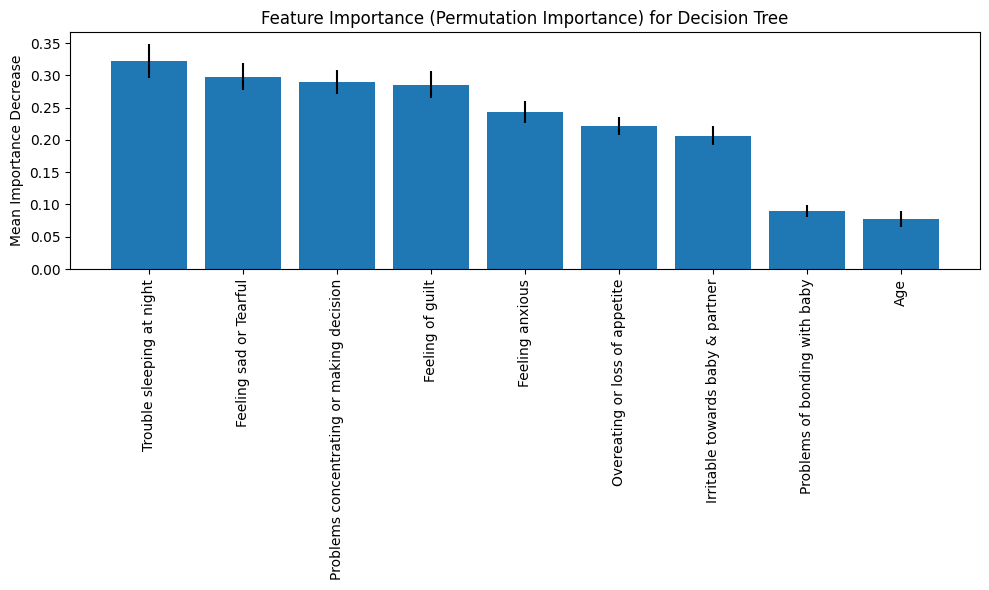

In [19]:
# Plot feature importance
plt.figure(figsize=(10, 6))
indices = np.argsort(importance_means)[::-1]
plt.bar(range(len(feature_names)), importance_means[indices], yerr=importance_std[indices], align='center')
plt.xticks(range(len(feature_names)), feature_names[indices], rotation=90)
plt.title('Feature Importance (Permutation Importance) for Decision Tree')
plt.ylabel('Mean Importance Decrease')
plt.tight_layout()
plt.show()

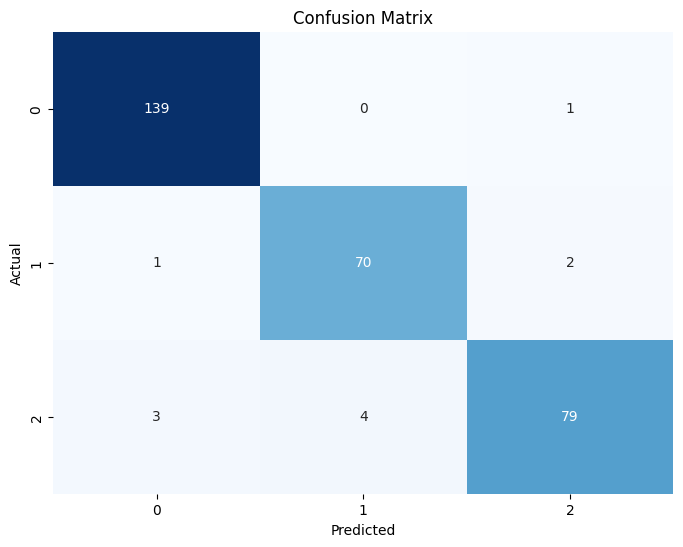

In [20]:
# Compute confusion matrix
cm = confusion_matrix(y_test, test_preds)

# Plot confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

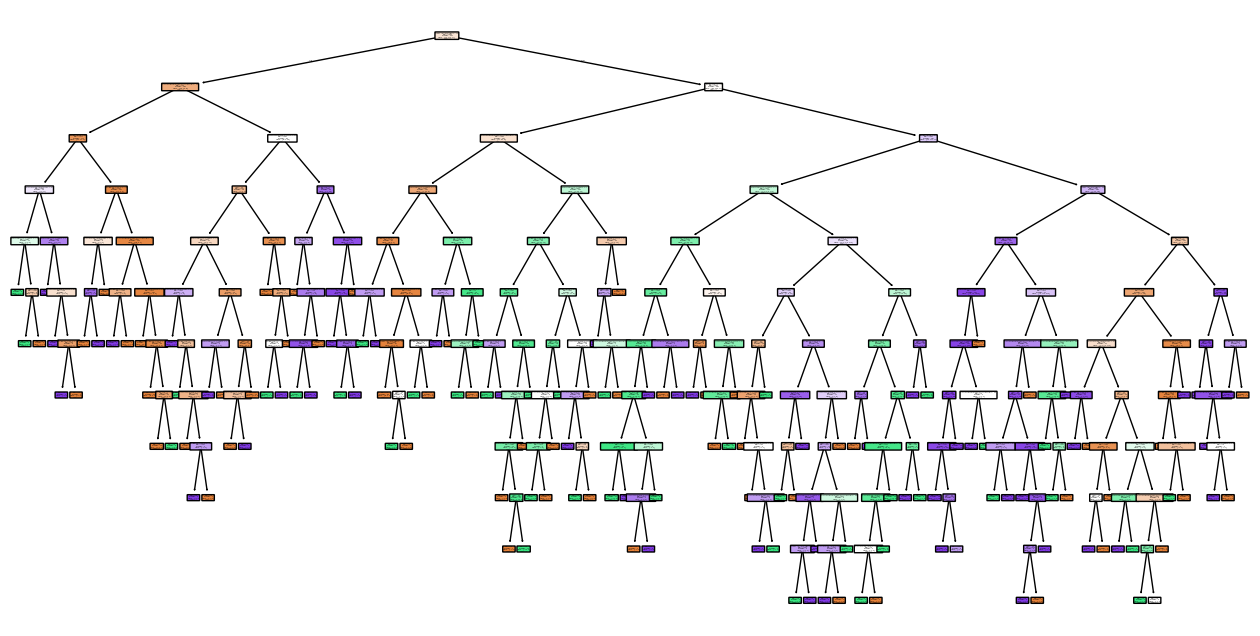

In [21]:
# Plot the structure of the trained decision tree
# - feature_names: labels for each input feature
# - class_names: labels for target classes
# - filled=True: color nodes based on the class
# - rounded=True: rounded corners for better readability

plt.figure(figsize=(16,8))
plot_tree(dt, feature_names=X.columns, class_names=[str(c) for c in np.unique(y)], filled=True, rounded=True)
plt.show()